# Clone Growth — No Treatment (Control Scenario)

Three clones are seeded at the start of every simulation:

| Clone | Name | Initial fraction | Growth multiplier | Radiosensitivity | Immune-kill |
|-------|------|-----------------|------------------|-----------------|-------------|
| 0 | Baseline | 60 % | ×1.0 | ×1.0 | ×1.0 |
| 1 | Proliferative | 25 % | ×1.1 | ×1.1 | ×1.1 |
| 2 | Invasive / Resistant | 15 % | ×0.95 | ×0.4 | ×0.3 |

This notebook uses the **Control** scenario CSVs (no radiation, immune suppression = 0.51) to show how each clone grows on its own.

## 1. Imports & setup

In [22]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

BASE_DIR  = "HALModeling2024Outs"
SCENARIO  = "Control"
FOLDER    = os.path.join(BASE_DIR, f"Scenario{SCENARIO}")

CLONE_COLS   = ["TumorClone0", "TumorClone1", "TumorClone2"]
CLONE_LABELS = ["Clone 0 – Baseline", "Clone 1 – Proliferative", "Clone 2 – Invasive/Resistant"]
CLONE_COLORS = ["#d62728", "#ff7f0e", "#8c564b"]   # red, orange, brown

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 2. Load all Control runs

In [23]:
csv_files = sorted(glob.glob(os.path.join(FOLDER, "TrialRunCounts_*.csv")))
print(f"Found {len(csv_files)} Control run(s):")
for f in csv_files:
    print(" ", os.path.basename(f))

runs = [pd.read_csv(f) for f in csv_files]
print(f"\nColumns: {list(runs[0].columns)}")

Found 10 Control run(s):
  TrialRunCounts_20260423_020700.csv
  TrialRunCounts_20260423_020710.csv
  TrialRunCounts_20260423_020718.csv
  TrialRunCounts_20260423_020727.csv
  TrialRunCounts_20260423_020736.csv
  TrialRunCounts_20260423_020744.csv
  TrialRunCounts_20260423_020753.csv
  TrialRunCounts_20260423_020802.csv
  TrialRunCounts_20260423_020811.csv
  TrialRunCounts_20260423_020820.csv

Columns: ['Timestep', 'Lymphocytes', 'TriggeringCells', 'TumorCells', 'TumorCellsRad', 'DoomedCells', 'DoomedCellsRad', 'DoomedCellsImm', 'Lymphocytes DieProb', 'Tumor DieProbRad', 'Tumor DieProbImm', 'Tumor DivProb', 'SurvivingFractionTLast', 'PrimaryImmuneResponse', 'SecondaryImmuneResponse', 'ImmuneResponse', 'LymphocyteMigrationAttempted', 'ImmuneSuppression', 'TumorClone0', 'TumorClone1', 'TumorClone2', 'TumorClone0Rad', 'TumorClone1Rad', 'TumorClone2Rad', 'Clone0DieProbRad', 'Clone0DieProbImm', 'Clone0DivProb', 'Clone1DieProbRad', 'Clone1DieProbImm', 'Clone1DivProb', 'Clone2DieProbRad', 'Clo

## 3. Individual clone growth — separate plots

Each panel shows one clone across all runs (thin lines) plus the mean (thick line).

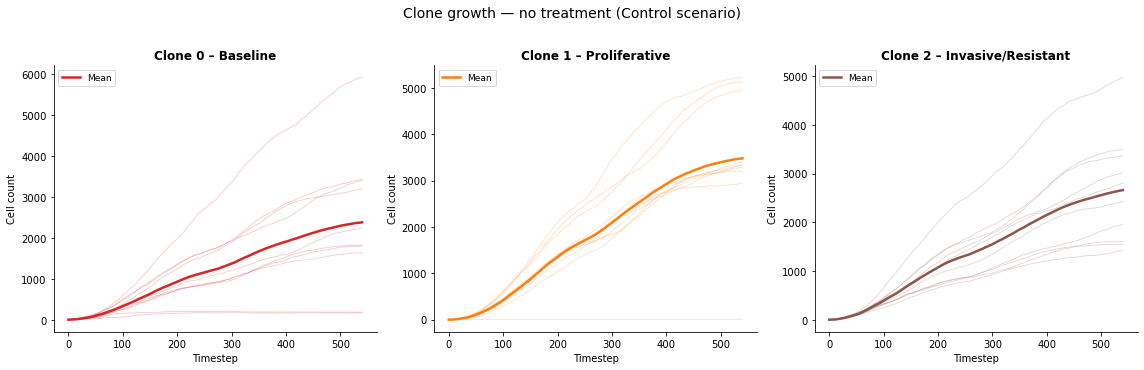

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, col, label, color in zip(axes, CLONE_COLS, CLONE_LABELS, CLONE_COLORS):
    # individual runs
    all_series = []
    for df in runs:
        t = df["Timestep"]
        y = df[col]
        ax.plot(t, y, color=color, alpha=0.25, linewidth=0.8)
        all_series.append(y.values)

    # mean across runs
    mean_y = np.mean(all_series, axis=0)
    ax.plot(runs[0]["Timestep"], mean_y, color=color, linewidth=2.5, label="Mean")

    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Cell count")
    ax.legend(fontsize=9)

fig.suptitle("Clone growth — no treatment (Control scenario)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. All three clones on one plot (mean ± std)

Easier to compare relative growth rates side-by-side.

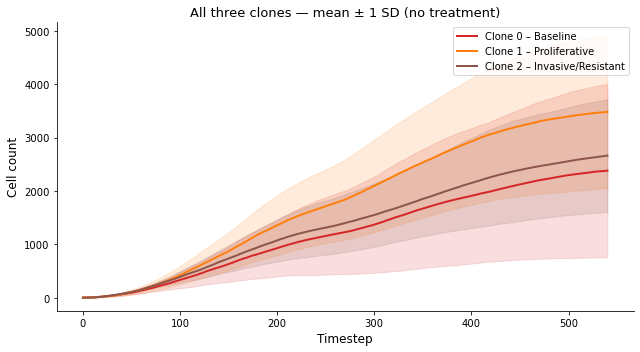

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))

t = runs[0]["Timestep"].values

for col, label, color in zip(CLONE_COLS, CLONE_LABELS, CLONE_COLORS):
    matrix = np.stack([df[col].values for df in runs])  # shape (n_runs, n_timesteps)
    mean   = matrix.mean(axis=0)
    std    = matrix.std(axis=0)

    ax.plot(t, mean, color=color, linewidth=2, label=label)
    ax.fill_between(t, mean - std, mean + std, color=color, alpha=0.15)

ax.set_xlabel("Timestep", fontsize=12)
ax.set_ylabel("Cell count", fontsize=12)
ax.set_title("All three clones — mean ± 1 SD (no treatment)", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 5. Clone fractions over time

Which clone is *winning* the competition?

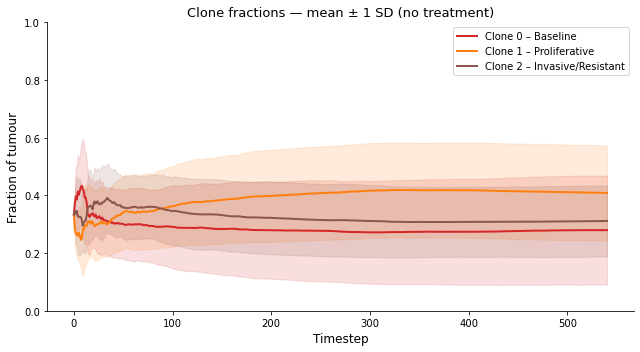

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))

eps = 1e-9

for col, label, color in zip(CLONE_COLS, CLONE_LABELS, CLONE_COLORS):
    fracs = []
    for df in runs:
        total = df[CLONE_COLS].sum(axis=1) + eps
        fracs.append((df[col] / total).values)

    fracs = np.stack(fracs)
    mean  = fracs.mean(axis=0)
    std   = fracs.std(axis=0)

    ax.plot(t, mean, color=color, linewidth=2, label=label)
    ax.fill_between(t, mean - std, mean + std, color=color, alpha=0.15)

ax.set_ylim(0, 1)
ax.set_xlabel("Timestep", fontsize=12)
ax.set_ylabel("Fraction of tumour", fontsize=12)
ax.set_title("Clone fractions — mean ± 1 SD (no treatment)", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 6. Early-growth zoom (first 100 timesteps)

The three clones start as single cells — this zooms in on the exponential phase.

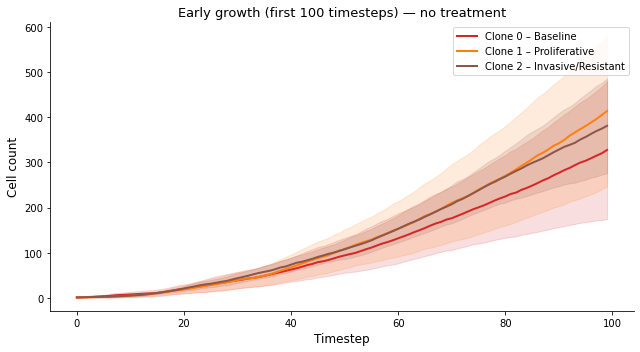

In [27]:
ZOOM = 100

fig, ax = plt.subplots(figsize=(9, 5))

for col, label, color in zip(CLONE_COLS, CLONE_LABELS, CLONE_COLORS):
    matrix = np.stack([df[col].values[:ZOOM] for df in runs])
    mean   = matrix.mean(axis=0)
    std    = matrix.std(axis=0)

    ax.plot(t[:ZOOM], mean, color=color, linewidth=2, label=label)
    ax.fill_between(t[:ZOOM], mean - std, mean + std, color=color, alpha=0.15)

ax.set_xlabel("Timestep", fontsize=12)
ax.set_ylabel("Cell count", fontsize=12)
ax.set_title(f"Early growth (first {ZOOM} timesteps) — no treatment", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 7. Doubling-time estimate (exponential fit)

Fit `N(t) = N0 * exp(r*t)` to the early growth phase to extract a growth rate **r** and doubling time **T₂ = ln(2)/r** for each clone.

Clone                                 Growth rate r     Doubling time T₂
------------------------------------------------------------------------
Clone 0 – Baseline                          0.01795                 38.6 timesteps
Clone 1 – Proliferative                     0.01936                 35.8 timesteps
Clone 2 – Invasive/Resistant                0.01790                 38.7 timesteps


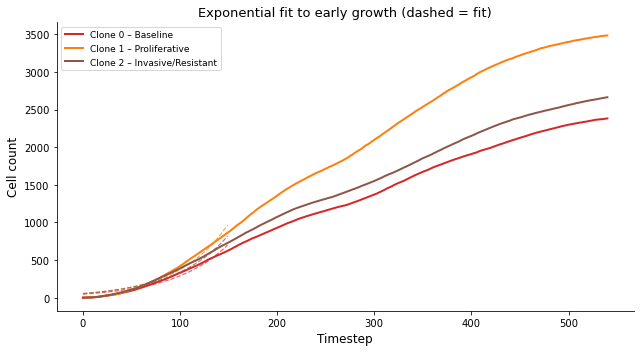

In [28]:
from scipy.optimize import curve_fit

FIT_END = 150   # timesteps to use for the exponential fit

def exp_model(t, N0, r):
    return N0 * np.exp(r * t)

print(f"{'Clone':<35} {'Growth rate r':>15} {'Doubling time T₂':>20}")
print("-" * 72)

fig, ax = plt.subplots(figsize=(9, 5))

for col, label, color in zip(CLONE_COLS, CLONE_LABELS, CLONE_COLORS):
    matrix = np.stack([df[col].values for df in runs])
    mean   = matrix.mean(axis=0)

    t_fit = t[:FIT_END].astype(float)
    y_fit = mean[:FIT_END]

    # only fit where count > 0
    mask = y_fit > 0
    try:
        popt, _ = curve_fit(exp_model, t_fit[mask], y_fit[mask],
                            p0=[1.0, 0.05], maxfev=5000)
        r      = popt[1]
        T2     = np.log(2) / r if r > 0 else float("inf")
        print(f"{label:<35} {r:>15.5f} {T2:>20.1f} timesteps")

        ax.plot(t, mean, color=color, linewidth=2, label=label)
        ax.plot(t_fit, exp_model(t_fit, *popt), "--", color=color,
                linewidth=1.2, alpha=0.7, label=f"_fit T₂={T2:.0f}")
    except RuntimeError:
        print(f"{label:<35} fit did not converge")
        ax.plot(t, mean, color=color, linewidth=2, label=label)

ax.set_xlabel("Timestep", fontsize=12)
ax.set_ylabel("Cell count", fontsize=12)
ax.set_title("Exponential fit to early growth (dashed = fit)", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()